# Lab 8 - Exploracion y analisis con DuckDB (Ejercicios 3, 4 y 8)

Este notebook **no contiene SQL propio**: ejecuta los archivos de `sql/` con las
vistas de `sql/00_vistas.sql`, que leen directamente los Parquet de `data/raw/`.
Asi la consulta documentada y la que produce cada tabla o grafica son la misma.

- Ejercicios 3 y 4 se corren sobre **2026** (el conjunto inicial del laboratorio).
- Ejercicio 8 corre **las mismas consultas** sobre todos los anios descargados.

La interpretacion completa esta en `docs/ej3-consultas.md`, `docs/ej4-eda.md` y
`docs/ej8-evolucion.md`. Las graficas se guardan en `docs/img/`.

Requisitos: datos descargados con `scripts/download_data.py --anios 2024 2025 2026`
y zonas con `scripts/download_zones.py`.

In [1]:
import os
import sys
import time
from pathlib import Path

# El notebook vive en notebooks/; las vistas usan rutas relativas a la raiz.
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(RAIZ)
sys.path.insert(0, str(RAIZ / "scripts"))

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
from run_sql import conectar

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

IMG = RAIZ / "docs" / "img"
IMG.mkdir(parents=True, exist_ok=True)

# Paleta validada (dataviz): color por entidad, nunca por posicion.
COLOR_TAXI = {"yellow": "#eda100", "green": "#008300"}
COLOR_ANIO = {2024: "#2a78d6", 2025: "#eb6834", 2026: "#1baf7a"}
TEXTO, TEXTO_2, REJILLA = "#0b0b0b", "#52514e", "#e4e3df"

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": REJILLA, "axes.labelcolor": TEXTO_2,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlecolor": TEXTO,
    "axes.grid": True, "grid.color": REJILLA, "grid.linewidth": 0.8,
    "xtick.color": TEXTO_2, "ytick.color": TEXTO_2,
    "lines.linewidth": 2, "legend.frameon": False,
    "font.size": 10,
})

con_2026 = conectar([2026])   # Ejercicios 3 y 4
con_todo = conectar()         # Ejercicio 8: todos los anios descargados

def sql(nombre, con):
    """Ejecuta sql/<nombre>.sql y devuelve un DataFrame."""
    inicio = time.perf_counter()
    df = con.sql((RAIZ / "sql" / f"{nombre}.sql").read_text(encoding="utf-8")).df()
    print(f"{nombre}: {len(df)} filas en {time.perf_counter() - inicio:.2f} s")
    return df

def eje_meses(eje):
    """Eje x de fechas mensuales: una marca cada 6 meses (ene / jul)."""
    eje.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7)))
    eje.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

def guardar(fig, nombre):
    fig.savefig(IMG / f"{nombre}.png")
    plt.show()

## Ejercicio 3 - Consultas directas sobre Parquet (2026)

Cada consulta lee los Parquet sin importarlos. La documentacion de cada una
(objetivo, fuente, resultado y decision) esta en `docs/ej3-consultas.md`.

In [2]:
sql("03_01_archivos", con_2026)

03_01_archivos: 2 filas en 0.00 s


,taxi,anio,archivos,primer_mes,ultimo_mes
0,green,2026,8,2026-01,2026-08
1,yellow,2026,8,2026-01,2026-08


In [3]:
sql("03_02_registros", con_2026)

03_02_registros: 2 filas en 0.01 s


,taxi,anio,registros,pct_del_total
0,green,2026,337114,1.12
1,yellow,2026,29703355,98.88


In [4]:
sql("03_03_registros_por_archivo", con_2026)

03_03_registros_por_archivo: 16 filas en 0.00 s


,taxi,mes,registros,relativo_al_promedio
0,green,2026-01,40272,0.96
1,green,2026-02,37373,0.89
2,green,2026-03,44208,1.05
3,green,2026-04,44238,1.05
4,green,2026-05,44921,1.07
5,green,2026-06,44163,1.05
6,green,2026-07,41252,0.98
7,green,2026-08,40687,0.97
8,yellow,2026-01,3724889,1.00
9,yellow,2026-02,3399866,0.92


In [5]:
sql("03_04_columnas_y_tipos", con_2026)

03_04_columnas_y_tipos: 43 filas en 0.01 s


,taxi,columna,tipo
0,yellow,Airport_fee,DOUBLE
1,yellow,DOLocationID,INTEGER
2,yellow,PULocationID,INTEGER
3,yellow,RatecodeID,BIGINT
4,yellow,VendorID,INTEGER
5,yellow,cbd_congestion_fee,DOUBLE
6,yellow,congestion_surcharge,DOUBLE
7,yellow,extra,DOUBLE
8,yellow,fare_amount,DOUBLE
9,yellow,improvement_surcharge,DOUBLE


In [6]:
sql("03_05_esquema_por_archivo", con_2026)

03_05_esquema_por_archivo: 2 filas en 0.02 s


,taxi,columna,tipos_fisicos,archivos_con_columna,archivos_totales,desde,hasta
0,yellow,request_source,BYTE_ARRAY,3,8,2026-06,2026-08
1,green,request_source,BYTE_ARRAY,3,8,2026-06,2026-08


In [7]:
sql("03_06_muestra", con_2026)

03_06_muestra: 10 filas en 0.39 s


,taxi,vendor_id,pickup,dropoff,passenger_count,trip_distance,ratecode_id,store_and_fwd_flag,pu_location_id,do_location_id,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,cbd_congestion_fee,trip_type,request_source,anio_archivo,mes_archivo,duracion_min
0,yellow,2,2026-01-29 21:19:20,2026-01-29 21:46:57,1,3.73,1,N,48,79,1,26.8,1.00,0.5,6.51,0.0,1.0,39.06,2.50,0.0,0.75,<NA>,None,2026,1,27.616667
1,yellow,1,2026-01-31 17:40:42,2026-01-31 17:53:52,1,1.50,1,N,79,162,1,12.1,3.25,0.5,3.35,0.0,1.0,20.20,2.50,0.0,0.75,<NA>,None,2026,1,13.166667
2,yellow,1,2026-03-04 19:47:59,2026-03-04 19:52:09,1,0.50,1,N,170,164,1,5.8,5.75,0.5,2.60,0.0,1.0,15.65,2.50,0.0,0.75,<NA>,None,2026,3,4.166667
3,yellow,2,2026-06-17 22:26:52,2026-06-17 22:29:18,1,0.71,1,N,142,238,1,5.1,1.00,0.5,2.02,0.0,1.0,12.12,2.50,0.0,0.00,<NA>,None,2026,6,2.433333
4,yellow,2,2026-07-27 18:15:14,2026-07-27 18:35:19,1,1.44,1,N,48,164,1,17.0,2.50,0.5,4.85,0.0,1.0,29.10,2.50,0.0,0.75,<NA>,None,2026,7,20.083333
5,green,2,2026-01-12 15:07:21,2026-01-12 15:20:28,1,1.62,1,N,97,181,1,12.8,0.00,0.5,4.00,0.0,1.0,18.30,0.00,NaN,0.00,1,None,2026,1,13.116667
6,green,2,2026-02-09 16:28:57,2026-02-09 16:44:10,1,2.76,1,N,74,262,1,16.3,2.50,0.5,2.80,0.0,1.0,25.85,2.75,NaN,0.00,1,None,2026,2,15.216667
7,green,6,2026-04-03 11:58:22,2026-04-03 12:41:28,<NA>,8.16,<NA>,NaN,61,216,<NA>,6.0,0.00,0.5,0.00,0.0,0.3,41.01,NaN,NaN,0.00,<NA>,None,2026,4,43.100000
8,green,2,2026-06-18 22:01:30,2026-06-18 22:31:28,1,4.25,1,N,33,255,1,31.0,1.00,0.5,6.70,0.0,1.0,40.20,0.00,NaN,0.00,1,None,2026,6,29.966667
9,green,2,2026-07-10 15:03:22,2026-07-10 15:10:15,1,1.00,1,N,43,236,1,8.6,0.00,0.5,2.57,0.0,1.0,15.42,2.75,NaN,0.00,1,None,2026,7,6.883333


In [8]:
sql("03_07_resumen_columnas", con_2026)

03_07_resumen_columnas: 25 filas en 4.29 s


,columna,tipo,min,max,distintos_aprox,avg,q25,q50,q75,pct_nulos
0,vendor_id,INTEGER,1,7,4,1.8907067995509657,2,2,2,0.00
1,pickup,TIMESTAMP,2001-01-01 09:23:58,2026-08-31 23:59:59,16867928,2026-04-30 16:00:25.430701,2026-03-03 21:08:13.501837,2026-05-01 06:37:38.894689,2026-06-26 05:30:36.568579,0.00
2,dropoff,TIMESTAMP,2001-01-01 16:09:38,2026-09-02 09:39:37,16587125,2026-04-30 16:18:06.219234,2026-03-04 01:14:14.758063,2026-04-30 22:25:09.301203,2026-06-26 07:07:48.332454,0.00
3,passenger_count,BIGINT,0,9,11,1.2500947923425925,1,1,1,25.85
4,trip_distance,DOUBLE,0.0,328522.2,7217,5.640433192969552,1.023727820146246,1.8586228128754823,3.8102105957530346,0.00
5,ratecode_id,BIGINT,1,99,7,4.4851104866144595,1,1,1,25.85
6,store_and_fwd_flag,VARCHAR,N,Y,2,NaN,NaN,NaN,NaN,25.85
7,pu_location_id,INTEGER,1,265,290,160.85691335245133,115,161,233,0.00
8,do_location_id,INTEGER,1,265,298,160.84743873339661,109,162,234,0.00
9,payment_type,BIGINT,0,5,6,0.8658841344540258,0,1,1,0.16


In [9]:
sql("03_08_calidad_fechas", con_2026)

03_08_calidad_fechas: 2 filas en 0.14 s


,taxi,registros,pickup_minimo,pickup_maximo,fuera_de_su_mes,duracion_negativa,duracion_cero,duracion_mayor_6h,duracion_cerca_24h,pct_duracion_invalida
0,yellow,29703355,2001-01-01 09:23:58,2026-08-31 23:59:59,146,10,371673,7315,3784,1.276
1,green,337114,2008-12-31 17:35:31,2026-08-31 23:58:28,98,5,229,1104,717,0.397


In [10]:
sql("03_09_calidad_montos_distancias", con_2026)

03_09_calidad_montos_distancias: 2 filas en 0.19 s


,taxi,anio,registros,distancia_cero,distancia_mayor_200mi,distancia_maxima,tarifa_negativa,tarifa_cero,total_negativo,total_mayor_1000,total_maximo,velocidad_mayor_80mph
0,yellow,2026,29703355,952231,704,328522.20,157364,22387,161835,49,7053.5,7987
1,green,2026,337114,12212,69,179830.92,999,4880,1023,1,1678.2,1158


In [11]:
sql("03_10_calidad_codigos_y_nulos", con_2026)

03_10_calidad_codigos_y_nulos: 2 filas en 0.06 s


,taxi,anio,registros,pct_pasajeros_nulo,pct_pasajeros_cero,pct_ratecode_nulo,pct_ratecode_99,pct_pago_0,pct_pago_nulo,pct_zona_desconocida,nulos_en_bloque
0,yellow,2026,29703355,25.98,0.31,25.98,2.59,25.98,0.00,0.17,7716688
1,green,2026,337114,14.47,1.34,14.47,0.00,0.00,14.47,0.34,48775


In [12]:
sql("03_11_pago_sin_detalle_por_mes", con_2026)

03_11_pago_sin_detalle_por_mes: 16 filas en 0.04 s


,taxi,anio,mes,registros,sin_detalle,pct_sin_detalle,propina_prom_sin_detalle,propina_prom_tarjeta
0,yellow,2026,1,3724889,1088058,29.2,0.38,4.14
1,yellow,2026,2,3399866,1023317,30.1,0.41,4.17
2,yellow,2026,3,3952451,945748,23.9,0.45,4.16
3,yellow,2026,4,3831240,799786,20.9,0.45,4.22
4,yellow,2026,5,4090836,955371,23.4,0.48,4.30
5,yellow,2026,6,3837248,1013500,26.4,0.39,4.55
6,yellow,2026,7,3530109,969727,27.5,0.32,4.38
7,yellow,2026,8,3336716,921181,27.6,0.31,4.31
8,green,2026,1,40272,5414,13.4,1.01,3.59
9,green,2026,2,37373,5387,14.4,1.02,3.69


In [13]:
sql("03_12_tarifas_negativas", con_2026)

03_12_tarifas_negativas: 10 filas en 0.68 s


,taxi,vendor_id,payment_type,tarifas_negativas,pct_de_negativas,con_viaje_espejo
0,yellow,2,4,100849,63.68,89319
1,yellow,2,2,35068,22.14,31126
2,yellow,2,3,17726,11.19,16029
3,yellow,2,1,3500,2.21,3229
4,green,2,3,564,0.36,560
5,green,2,4,279,0.18,267
6,yellow,2,0,221,0.14,0
7,green,2,1,137,0.09,133
8,green,2,2,17,0.01,14
9,green,2,<NA>,2,0.00,0


In [14]:
sql("03_13_duplicados", con_2026)

03_13_duplicados: 1 filas en 0.86 s


,taxi,grupos_duplicados,registros_sobrantes,max_repeticiones
0,yellow,7,7.0,2


In [15]:
sql("03_14_impacto_limpieza", con_2026)

03_14_impacto_limpieza: 2 filas en 0.35 s


,taxi,anio,registros,r1_fecha_fuera_de_mes,r2_duracion,r3_distancia,r4_montos_no_positivos,r5_total_extremo,r6_velocidad,conservados,descartados,pct_conservado
0,yellow,2026,29703355,146,378998,952935,180386,49,7987,28215140,1488215,94.99
1,green,2026,337114,98,1338,12281,6196,1,1158,316958,20156,94.02


In [16]:
sql("03_15_consistencia_total", con_2026)

03_15_consistencia_total: 11 filas en 0.21 s


,taxi,vendor_id,tipo_registro,registros,pct_total_no_cuadra,diferencia_mas_frecuente
0,yellow,1,taximetro (pago 1-6),4571690,83.38,-3.25
1,yellow,1,sin detalle (Flex Fare),895381,98.43,2.50
2,yellow,2,taximetro (pago 1-6),17047857,0.13,2.50
3,yellow,2,sin detalle (Flex Fare),6761917,88.19,2.50
4,yellow,6,sin detalle (Flex Fare),59390,100.00,12.20
5,yellow,7,taximetro (pago 1-6),367120,42.84,1.00
6,green,1,taximetro (pago 1-6),28168,97.04,-1.00
7,green,1,sin detalle (Flex Fare),528,64.20,2.75
8,green,2,taximetro (pago 1-6),260171,0.04,2.50
9,green,2,sin detalle (Flex Fare),13400,32.43,2.75


### Que pasa sin `union_by_name`

Las columnas `request_source` (junio-agosto 2026) y `cbd_congestion_fee` (desde
2025) no estan en todos los archivos. Leyendo sin `union_by_name`, DuckDB usa el
esquema del primer archivo y la columna no existe:

In [17]:
import duckdb
for opcion in ["", ", union_by_name = true"]:
    try:
        r = duckdb.sql(f"SELECT count(request_source) FROM read_parquet('data/raw/yellow/2026/*.parquet'{opcion})").fetchone()
        print(f"read_parquet(...{opcion}) -> {r[0]:,} filas con request_source")
    except duckdb.Error as e:
        print(f"read_parquet(...{opcion}) -> ERROR: {str(e).splitlines()[0]}")

read_parquet(...) -> ERROR: Binder Error: Referenced column "request_source" not found in FROM clause!
read_parquet(..., union_by_name = true) -> 2,903,446 filas con request_source


## Ejercicio 4 - Analisis exploratorio (2026, vista `viajes_limpios`)

Las preguntas y su justificacion estan en `docs/ej4-eda.md`.

### P1. Viajes por mes

In [18]:
mes = sql("04_01_viajes_por_mes", con_2026)
mes

04_01_viajes_por_mes: 16 filas en 0.31 s


,taxi,mes,viajes,viajes_por_dia,indice_vs_primer_mes
0,yellow,2026-01-01,3514926,113385.0,100.0
1,yellow,2026-02-01,3208536,114591.0,91.3
2,yellow,2026-03-01,3760435,121304.0,107.0
3,yellow,2026-04-01,3671806,122394.0,104.5
4,yellow,2026-05-01,3909805,126123.0,111.2
5,yellow,2026-06-01,3643971,121466.0,103.7
6,yellow,2026-07-01,3343969,107870.0,95.1
7,yellow,2026-08-01,3161692,101990.0,90.0
8,green,2026-01-01,38086,1229.0,100.0
9,green,2026-02-01,35112,1254.0,92.2


### P2. Hora del dia y dia de la semana

04_02_hora_y_dia_semana: 336 filas en 0.23 s


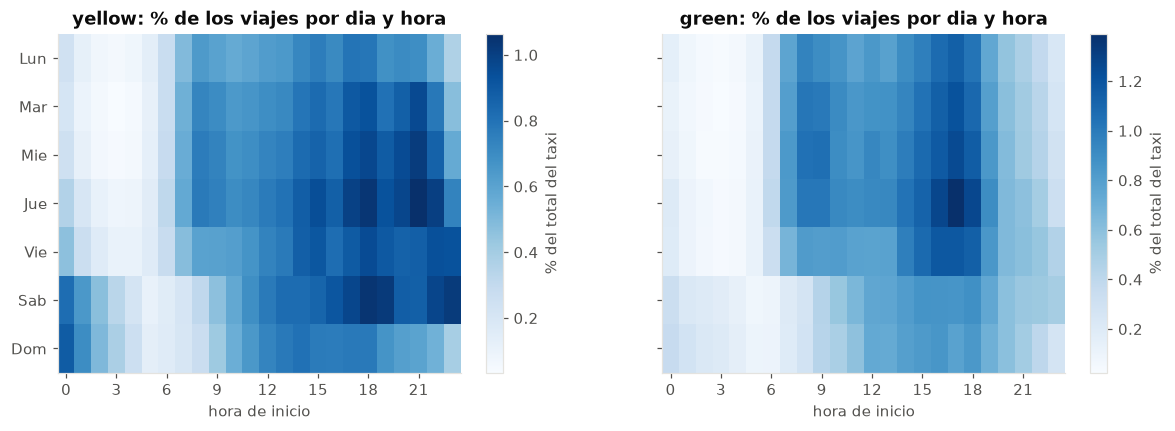

,Lun,Mar,Mie,Jue,Vie,Sab,Dom
taxi,,,,,,,
green,14.2,15.1,15.7,16.5,15.0,12.1,11.4
yellow,11.9,13.6,14.5,15.8,15.0,16.0,13.3


In [19]:
hd = sql("04_02_hora_y_dia_semana", con_2026)
dias = ["Lun", "Mar", "Mie", "Jue", "Vie", "Sab", "Dom"]
fig, ejes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for eje, taxi in zip(ejes, ["yellow", "green"]):
    m = hd[hd.taxi == taxi].pivot(index="dia_semana", columns="hora", values="pct_del_taxi")
    im = eje.imshow(m.values, aspect="auto", cmap="Blues")
    eje.set_title(f"{taxi}: % de los viajes por dia y hora")
    eje.set_yticks(range(7), dias)
    eje.set_xticks(range(0, 24, 3))
    eje.set_xlabel("hora de inicio")
    eje.grid(False)
    fig.colorbar(im, ax=eje, label="% del total del taxi")
guardar(fig, "04_02_hora_dia_semana")

# Resumen por dia de la semana (% del total de cada taxi)
hd.groupby(["taxi", "dia_semana"]).pct_del_taxi.sum().unstack().round(1).set_axis(dias, axis=1)

### P3 y P4. Caracteristicas del viaje y velocidad por hora

04_03_caracteristicas_viaje: 2 filas en 0.60 s


,taxi,viajes,distancia_p25,distancia_mediana,distancia_p75,distancia_p99,distancia_promedio,duracion_mediana_min,duracion_p99_min,velocidad_mediana_mph,pasajeros_promedio,pct_un_pasajero
0,yellow,28215140,1.10,1.93,3.95,19.55,3.51,14.1,71.5,9.3,1.25,82.3
1,green,316958,1.32,2.12,3.72,17.57,3.30,13.2,73.9,10.0,1.30,82.8


04_04_velocidad_por_hora: 24 filas en 0.43 s


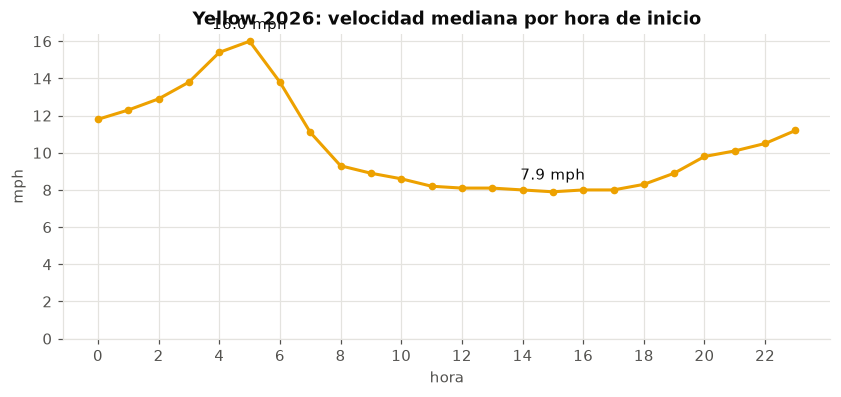

In [20]:
display(sql("04_03_caracteristicas_viaje", con_2026))
vel = sql("04_04_velocidad_por_hora", con_2026)
fig, eje = plt.subplots(figsize=(9, 3.6))
eje.plot(vel.hora, vel.velocidad_mediana_mph, color=COLOR_TAXI["yellow"], marker="o", markersize=4)
for h in [5, 15]:
    fila = vel[vel.hora == h].iloc[0]
    eje.annotate(f"{fila.velocidad_mediana_mph} mph", (h, fila.velocidad_mediana_mph),
                 textcoords="offset points", xytext=(0, 8), ha="center", color=TEXTO)
eje.set_title("Yellow 2026: velocidad mediana por hora de inicio")
eje.set_xlabel("hora"); eje.set_ylabel("mph"); eje.set_xticks(range(0, 24, 2))
eje.set_ylim(0, None)
guardar(fig, "04_04_velocidad_por_hora")

### P5. Donde operan yellow y green

04_05_zonas_por_borough: 15 filas en 0.29 s


,taxi,borough_origen,viajes,pct_del_taxi,pct_termina_mismo_borough
0,yellow,Manhattan,24448923,86.65,92.7
1,yellow,Queens,2495282,8.84,27.0
2,yellow,Brooklyn,1014356,3.60,48.0
3,yellow,Bronx,217623,0.77,32.4
4,yellow,Unknown,29367,0.10,33.9
5,yellow,N/A,6121,0.02,54.7
6,yellow,Staten Island,2582,0.01,30.4
7,yellow,EWR,886,0.00,83.9
8,green,Manhattan,190054,59.96,91.2
9,green,Queens,70056,22.10,84.4


04_06_zonas_top: 20 filas en 0.27 s


,taxi,puesto,borough,zona,viajes,pct_del_taxi
0,yellow,1,Manhattan,Upper East Side South,1252548,4.44
1,yellow,2,Manhattan,Midtown Center,1171287,4.15
2,yellow,3,Queens,JFK Airport,1124910,3.99
3,yellow,4,Manhattan,Upper East Side North,1112988,3.94
4,yellow,5,Manhattan,Penn Station/Madison Sq West,868453,3.08
5,yellow,6,Manhattan,Midtown East,864395,3.06
6,yellow,7,Manhattan,Times Sq/Theatre District,817167,2.90
7,yellow,8,Manhattan,Lincoln Square East,811470,2.88
8,yellow,9,Manhattan,East Village,756136,2.68
9,yellow,10,Manhattan,Murray Hill,737331,2.61


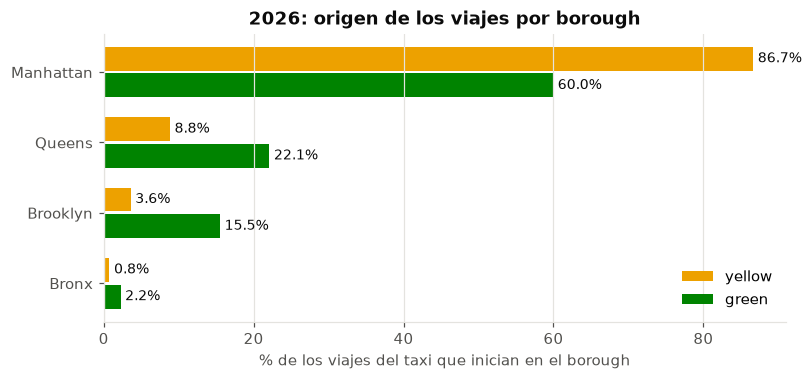

In [21]:
bor = sql("04_05_zonas_por_borough", con_2026)
display(bor)
display(sql("04_06_zonas_top", con_2026))
orden = ["Manhattan", "Queens", "Brooklyn", "Bronx"]
p = bor[bor.borough_origen.isin(orden)].pivot(index="borough_origen", columns="taxi", values="pct_del_taxi").loc[orden[::-1]]
fig, eje = plt.subplots(figsize=(8, 3.4))
alto = 0.38
for i, taxi in enumerate(["green", "yellow"]):
    y = [k + (i - 0.5) * alto for k in range(len(p))]
    barras = eje.barh(y, p[taxi], height=alto - 0.04, color=COLOR_TAXI[taxi], label=taxi)
    eje.bar_label(barras, fmt="%.1f%%", padding=3, color=TEXTO, fontsize=9)
eje.set_yticks(range(len(p)), p.index)
eje.set_xlabel("% de los viajes del taxi que inician en el borough")
eje.set_title("2026: origen de los viajes por borough")
manejadores, nombres = eje.get_legend_handles_labels()
eje.legend(manejadores[::-1], nombres[::-1], loc="lower right")
eje.grid(axis="y", visible=False)
guardar(fig, "04_05_borough_origen")

### P6. Yellow vs green por viaje

In [22]:
sql("04_07_yellow_vs_green", con_2026)

04_07_yellow_vs_green: 2 filas en 0.32 s


,taxi,viajes,tarifa_mediana,tarifa_promedio,total_promedio,tarifa_por_milla,recargo_congestion_prom,cargo_cbd_prom,peajes_prom,pct_aeropuerto_jfk_newark,pct_tarifa_negociada,pct_despacho_green
0,yellow,28215140,15.72,21.3,30.25,7.37,2.26,0.54,0.55,2.63,0.55,NaN
1,green,316958,13.41,17.0,25.35,6.24,0.92,0.06,0.29,0.25,3.59,3.48


### P7 y P8. Pago y propinas

04_08_metodos_pago: 10 filas en 0.25 s


,taxi,metodo_pago,viajes,pct_del_taxi,total_promedio,propina_promedio
0,yellow,1 - tarjeta,18453029,65.40,30.02,4.26
1,yellow,0/nulo - sin detalle (Flex Fare),7033607,24.93,32.45,0.40
2,yellow,2 - efectivo,2554879,9.05,26.05,0.00
3,yellow,4 - disputa,117824,0.42,28.89,0.00
4,yellow,3 - sin cargo,55801,0.20,24.50,0.00
5,green,1 - tarjeta,210958,66.56,25.58,3.80
6,green,2 - efectivo,62448,19.70,20.81,0.00
7,green,0/nulo - sin detalle (Flex Fare),42666,13.46,31.01,0.85
8,green,3 - sin cargo,637,0.20,17.83,0.01
9,green,4 - disputa,249,0.08,20.58,0.00


04_09_propinas: 10 filas en 0.28 s


,taxi,distancia,viajes_tarjeta,pct_sin_propina,propina_pct_mediana,propina_promedio
0,yellow,1. < 1 mi,4394459,5.9,32.4,2.47
1,yellow,2. 1-3 mi,8929868,5.9,27.1,3.34
2,yellow,3. 3-7 mi,2708237,13.2,23.7,4.94
3,yellow,4. 7-15 mi,1541226,22.6,22.6,8.38
4,yellow,5. 15+ mi,879239,15.9,21.4,13.20
5,green,1. < 1 mi,27986,13.8,25.6,2.12
6,green,2. 1-3 mi,124680,6.9,24.0,3.06
7,green,3. 3-7 mi,44524,8.5,23.0,5.12
8,green,4. 7-15 mi,11954,12.5,21.2,8.72
9,green,5. 15+ mi,1814,15.5,20.3,15.01


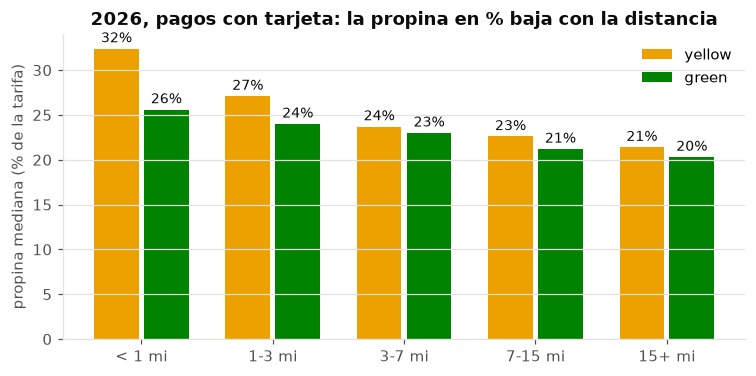

In [23]:
display(sql("04_08_metodos_pago", con_2026))
prop = sql("04_09_propinas", con_2026)
display(prop)
fig, eje = plt.subplots(figsize=(8, 3.6))
etiquetas = prop[prop.taxi == "yellow"].distancia.str[3:]
x = range(len(etiquetas))
for i, taxi in enumerate(["yellow", "green"]):
    d = prop[prop.taxi == taxi]
    barras = eje.bar([k + (i - 0.5) * 0.38 for k in x], d.propina_pct_mediana, width=0.34,
                     color=COLOR_TAXI[taxi], label=taxi)
    eje.bar_label(barras, fmt="%.0f%%", padding=2, color=TEXTO, fontsize=9)
eje.set_xticks(list(x), etiquetas)
eje.set_ylabel("propina mediana (% de la tarifa)")
eje.set_title("2026, pagos con tarjeta: la propina en % baja con la distancia")
eje.legend()
eje.grid(axis="x", visible=False)
guardar(fig, "04_09_propina_por_distancia")

### P9. Distribucion del total cobrado

04_10_distribucion_totales: 62 filas en 0.24 s


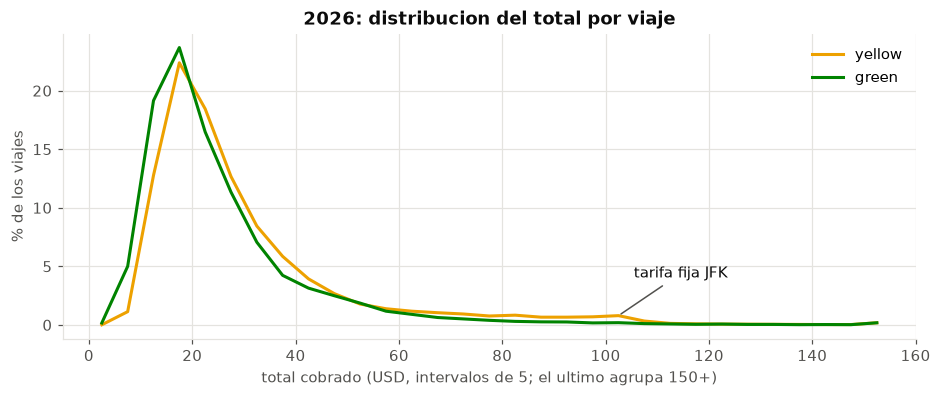

In [24]:
dist = sql("04_10_distribucion_totales", con_2026)
fig, eje = plt.subplots(figsize=(10, 3.6))
for taxi in ["yellow", "green"]:
    d = dist[dist.taxi == taxi]
    eje.plot(d.desde_usd + 2.5, d.pct_del_taxi, color=COLOR_TAXI[taxi], label=taxi)
eje.annotate("tarifa fija JFK", (102.5, dist[(dist.taxi == "yellow") & (dist.desde_usd == 100)].pct_del_taxi.iloc[0]),
             textcoords="offset points", xytext=(10, 25), arrowprops={"arrowstyle": "-", "color": TEXTO_2}, color=TEXTO)
eje.set_xlabel("total cobrado (USD, intervalos de 5; el ultimo agrupa 150+)")
eje.set_ylabel("% de los viajes")
eje.set_title("2026: distribucion del total por viaje")
eje.legend()
guardar(fig, "04_10_distribucion_totales")

### P10. Atipicos y viajes de aeropuerto

In [25]:
display(sql("04_11_atipicos_iqr", con_2026))
sql("04_12_aeropuertos", con_2026)

04_11_atipicos_iqr: 2 filas en 0.80 s


,taxi,viajes,limite_distancia,pct_atip_distancia,limite_duracion,pct_atip_duracion,limite_total,pct_atip_total,pct_propina_mayor_tarifa
0,yellow,28215140,8.22,10.92,42.7,5.41,60.05,8.51,0.101
1,green,316958,7.31,10.05,37.9,6.78,51.16,6.71,0.177


04_12_aeropuertos: 2 filas en 0.41 s


,tipo_viaje,viajes,pct_viajes,pct_ingresos,distancia_mediana,total_mediano,pct_total_mayor_100
0,urbano,25910941,91.83,78.95,1.77,22.48,0.29
1,aeropuerto,2304199,8.17,21.05,11.50,78.48,18.54


## Ejercicio 8 - Analisis con 2024, 2025 y 2026

### 8.3 Las consultas anteriores siguen funcionando

Se ejecutan **los mismos archivos** de los Ejercicios 3 y 4 sobre todos los
anios, sin modificar ninguna linea. Solo cambia la conexion (`con_todo`).

In [26]:
resumen = []
for archivo in sorted((RAIZ / "sql").glob("0[34]_*.sql")):
    inicio = time.perf_counter()
    filas = len(con_todo.sql(archivo.read_text(encoding="utf-8")).df())
    resumen.append({"consulta": archivo.stem, "filas": filas,
                    "segundos": round(time.perf_counter() - inicio, 2)})
pd.DataFrame(resumen)

,consulta,filas,segundos
0,03_01_archivos,6,0.00
1,03_02_registros,6,0.02
2,03_03_registros_por_archivo,64,0.01
3,03_04_columnas_y_tipos,43,0.01
4,03_05_esquema_por_archivo,4,0.01
5,03_06_muestra,10,1.49
6,03_07_resumen_columnas,25,16.22
7,03_08_calidad_fechas,2,0.46
8,03_09_calidad_montos_distancias,6,0.72
9,03_10_calidad_codigos_y_nulos,6,0.21


In [27]:
display(sql("03_02_registros", con_todo))
display(sql("03_05_esquema_por_archivo", con_todo))
sql("03_14_impacto_limpieza", con_todo)

03_02_registros: 6 filas en 0.02 s


,taxi,anio,registros,pct_del_total
0,green,2024,660218,0.54
1,green,2025,591375,0.49
2,green,2026,337114,0.28
3,yellow,2024,41169720,33.97
4,yellow,2025,48722602,40.21
5,yellow,2026,29703355,24.51


03_05_esquema_por_archivo: 4 filas en 0.01 s


,taxi,columna,tipos_fisicos,archivos_con_columna,archivos_totales,desde,hasta
0,yellow,cbd_congestion_fee,DOUBLE,20,32,2025-01,2026-08
1,yellow,request_source,BYTE_ARRAY,3,32,2026-06,2026-08
2,green,cbd_congestion_fee,DOUBLE,20,32,2025-01,2026-08
3,green,request_source,BYTE_ARRAY,3,32,2026-06,2026-08


03_14_impacto_limpieza: 6 filas en 1.22 s


,taxi,anio,registros,r1_fecha_fuera_de_mes,r2_duracion,r3_distancia,r4_montos_no_positivos,r5_total_extremo,r6_velocidad,conservados,descartados,pct_conservado
0,yellow,2024,41169720,420,35533,777447,748345,43,13245,39669674,1500046,96.36
1,yellow,2025,48722602,214,561220,1405196,2870701,85,13700,44144384,4578218,90.60
2,yellow,2026,29703355,146,378998,952935,180386,49,7987,28215140,1488215,94.99
3,green,2024,660218,164,3291,34807,2667,1,2147,619164,41054,93.78
4,green,2025,591375,248,4384,24638,5000,1,3540,555521,35854,93.94
5,green,2026,337114,98,1338,12281,6196,1,1158,316958,20156,94.02


### 8.5 Evolucion del volumen

08_01_volumen_mensual: 64 filas en 0.79 s


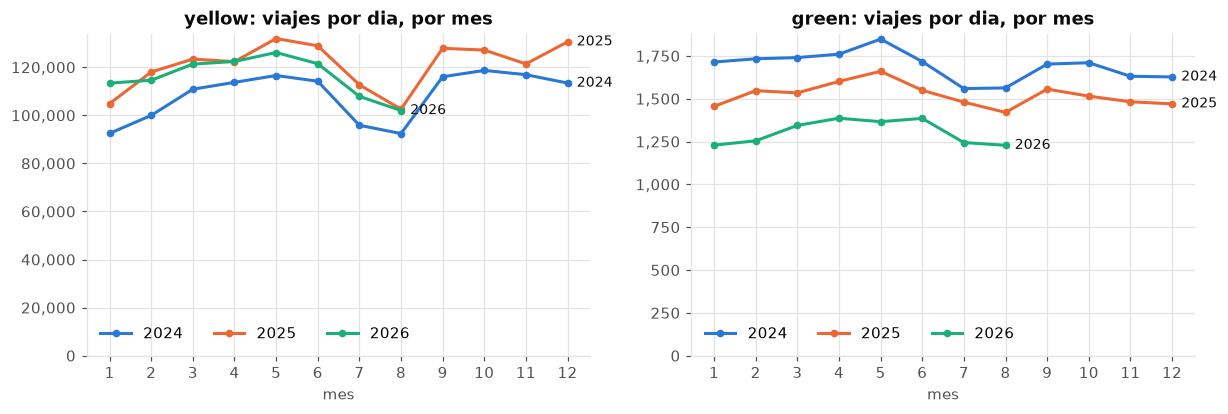

anio        2025  2026
taxi   mes            
green  1   -15.1 -15.6
       2   -13.8 -18.9
       3   -11.8 -12.4
       4    -9.0 -13.4
       5   -10.2 -17.7
       6    -9.8 -10.6
       7    -5.1 -15.9
       8    -9.2 -13.5
       9    -8.6   NaN
       10  -11.4   NaN
       11   -9.1   NaN
       12   -9.6   NaN
yellow 1    13.4   8.1
       2    14.0  -2.9
       3    11.3  -1.7
       4     7.6   0.1
       5    13.2  -4.4
       6    12.9  -5.8
       7    17.6  -4.3
       8    11.0  -0.5
       9    10.2   NaN
       10    7.1   NaN
       11    3.8   NaN
       12   15.1   NaN

In [28]:
vol = sql("08_01_volumen_mensual", con_todo)
fig, ejes = plt.subplots(1, 2, figsize=(13, 3.8))
for eje, taxi in zip(ejes, ["yellow", "green"]):
    for anio, d in vol[vol.taxi == taxi].groupby("anio"):
        eje.plot(d.mes, d.viajes_por_dia, color=COLOR_ANIO.get(anio, TEXTO_2), marker="o", markersize=4, label=anio)
        eje.annotate(str(anio), (d.mes.iloc[-1], d.viajes_por_dia.iloc[-1]), textcoords="offset points",
                     xytext=(6, 0), va="center", color=TEXTO, fontsize=9)
    eje.set_title(f"{taxi}: viajes por dia, por mes")
    eje.set_xticks(range(1, 13)); eje.set_xlabel("mes"); eje.set_ylim(0, None)
    eje.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
    eje.legend(loc="lower left", ncols=3)
guardar(fig, "08_01_viajes_por_dia")
vol.pivot_table(index=["taxi", "mes"], columns="anio", values="var_vs_anio_anterior_pct")

### 8.5 Comparacion en el periodo comun (meses presentes en todos los anios)

In [29]:
display(sql("08_02_comparacion_periodo_comun", con_todo))
sql("08_03_componentes_total", con_todo)

08_02_comparacion_periodo_comun: 6 filas en 2.47 s


,taxi,anio,meses,viajes,viajes_por_dia,distancia_mediana,duracion_mediana_min,velocidad_mediana_mph,tarifa_promedio,total_promedio,tarifa_por_milla,pct_tarjeta,pct_efectivo,pct_sin_detalle,propina_pct_mediana_tarjeta
0,yellow,2024,1-8,25487194,104456.0,1.80,12.7,9.5,19.53,28.33,6.88,75.9,13.8,9.0,25.9
1,yellow,2025,1-8,28678171,118017.0,1.87,13.0,9.7,19.58,28.34,6.77,68.7,10.0,19.6,26.6
2,yellow,2026,1-8,28215140,116112.0,1.93,14.1,9.3,21.30,30.25,7.37,65.4,9.1,24.9,26.4
3,green,2024,1-8,415732,1704.0,1.96,11.9,10.4,17.77,23.76,6.65,67.8,27.8,4.0,23.5
4,green,2025,1-8,371830,1530.0,2.02,12.4,10.3,18.01,24.84,6.56,70.0,23.3,6.4,23.4
5,green,2026,1-8,316958,1304.0,2.13,13.2,10.0,17.00,25.35,6.24,66.6,19.7,13.5,23.6


08_03_componentes_total: 6 filas en 1.80 s


,taxi,anio,tarifa,extra,mta_tax,improvement,congestion_surcharge,airport_fee,cbd_congestion_fee,peajes,propina,total,pct_cargos_en_total
0,yellow,2024,19.53,1.46,0.50,0.99,2.11,0.14,0.00,0.58,3.34,28.33,19.3
1,yellow,2025,19.58,1.32,0.50,0.99,1.85,0.12,0.55,0.53,3.02,28.34,20.3
2,yellow,2026,21.30,1.17,0.50,0.98,1.69,0.13,0.54,0.55,2.88,30.25,20.0
3,green,2024,17.77,0.97,0.56,0.99,0.82,0.00,0.00,0.21,2.59,23.76,14.3
4,green,2025,18.01,0.94,0.58,0.98,0.85,0.00,0.07,0.25,2.72,24.84,16.5
5,green,2026,17.00,0.85,0.56,0.93,0.79,0.00,0.06,0.29,2.64,25.35,22.5


### 8.6 Patron 1 - el cargo por congestion de Manhattan (enero 2025)

08_04_cargo_cbd_mensual: 64 filas en 0.96 s


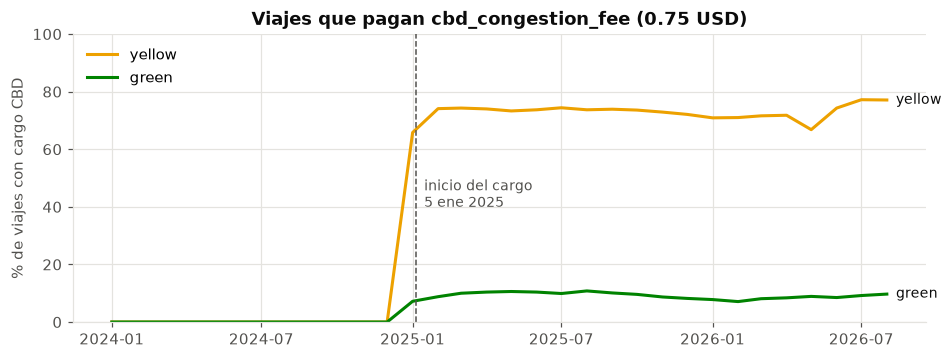

In [30]:
cbd = sql("08_04_cargo_cbd_mensual", con_todo)
fig, eje = plt.subplots(figsize=(10, 3.4))
for taxi in ["yellow", "green"]:
    d = cbd[cbd.taxi == taxi]
    eje.plot(d.mes, d.pct_con_cargo_cbd, color=COLOR_TAXI[taxi], label=taxi)
    eje.annotate(taxi, (d.mes.iloc[-1], d.pct_con_cargo_cbd.iloc[-1]), textcoords="offset points",
                 xytext=(6, 0), va="center", color=TEXTO, fontsize=9)
eje.axvline(pd.Timestamp("2025-01-05"), color=TEXTO_2, linewidth=1, linestyle="--")
eje.text(pd.Timestamp("2025-01-15"), 40, "inicio del cargo\n5 ene 2025", color=TEXTO_2, fontsize=9)
eje.set_ylabel("% de viajes con cargo CBD"); eje.set_ylim(0, 100)
eje_meses(eje)
eje.set_title("Viajes que pagan cbd_congestion_fee (0.75 USD)")
eje.legend(loc="upper left")
guardar(fig, "08_04_cargo_cbd")

08_05_velocidad_manhattan: 32 filas en 0.96 s


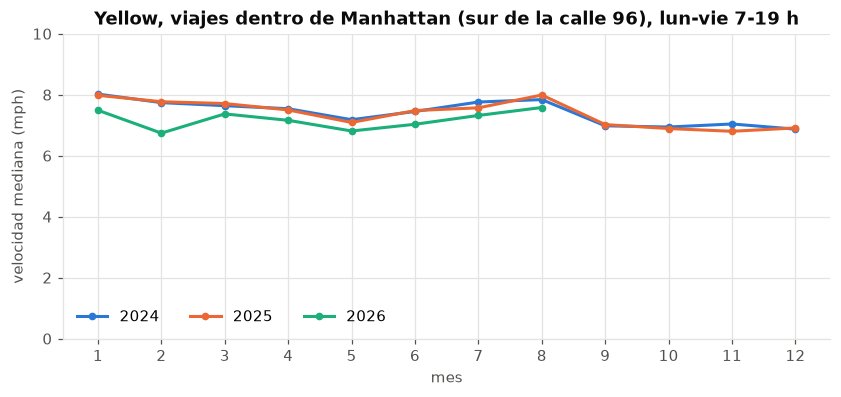

anio,2024,2025,2026
mes,,,
1,8.02,7.98,7.49
2,7.74,7.77,6.74
3,7.64,7.71,7.37
4,7.54,7.50,7.16
5,7.18,7.09,6.81
6,7.45,7.48,7.03
7,7.76,7.57,7.32
8,7.84,7.99,7.58
9,6.98,7.02,NaN


In [31]:
vm = sql("08_05_velocidad_manhattan", con_todo)
fig, eje = plt.subplots(figsize=(9, 3.6))
for anio, d in vm.groupby("anio"):
    eje.plot(d.mes, d.velocidad_mediana_mph, color=COLOR_ANIO.get(anio, TEXTO_2), marker="o", markersize=4, label=anio)
eje.set_title("Yellow, viajes dentro de Manhattan (sur de la calle 96), lun-vie 7-19 h")
eje.set_xlabel("mes"); eje.set_ylabel("velocidad mediana (mph)"); eje.set_xticks(range(1, 13))
eje.set_ylim(0, 10)
eje.legend(ncols=3, loc="lower left")
guardar(fig, "08_05_velocidad_manhattan")
vm.pivot(index="mes", columns="anio", values="velocidad_mediana_mph")

### 8.6 Patron 2 - crecen los registros sin detalle (Flex Fare)

08_06_pagos_mensual: 64 filas en 0.97 s


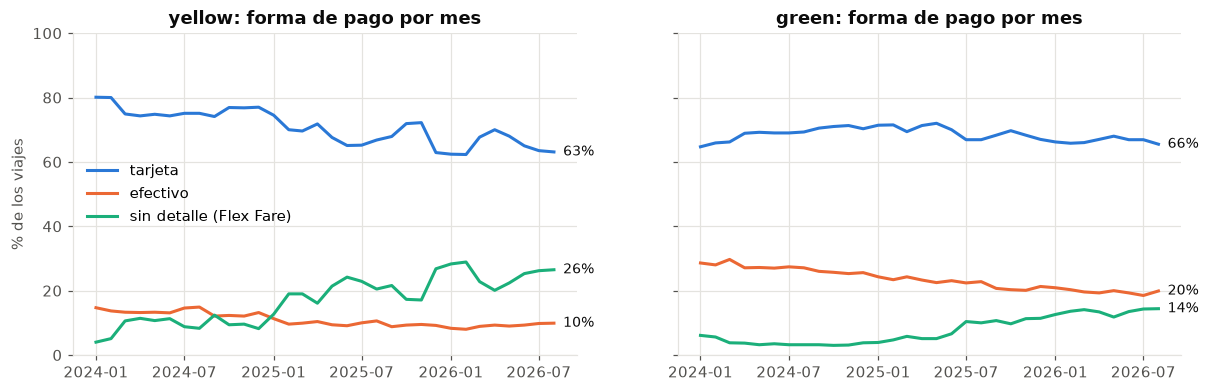

In [32]:
pag = sql("08_06_pagos_mensual", con_todo)
fig, ejes = plt.subplots(1, 2, figsize=(13, 3.8), sharey=True)
series = [("pct_tarjeta", "tarjeta", "#2a78d6"), ("pct_efectivo", "efectivo", "#eb6834"),
          ("pct_sin_detalle", "sin detalle (Flex Fare)", "#1baf7a")]
for eje, taxi in zip(ejes, ["yellow", "green"]):
    d = pag[pag.taxi == taxi]
    for col, nombre, color in series:
        eje.plot(d.mes, d[col], color=color, label=nombre)
        eje.annotate(f"{d[col].iloc[-1]:.0f}%", (d.mes.iloc[-1], d[col].iloc[-1]), textcoords="offset points",
                     xytext=(6, 0), va="center", color=TEXTO, fontsize=9)
    eje.set_title(f"{taxi}: forma de pago por mes")
    eje.set_ylim(0, 100)
    eje_meses(eje)
ejes[0].set_ylabel("% de los viajes")
ejes[0].legend(loc="center left")
guardar(fig, "08_06_forma_de_pago")

08_08_tarifa_por_tipo_registro: 12 filas en 1.88 s


,taxi,anio,tipo_registro,viajes,pct_del_anio,tarifa_promedio,tarifa_mediana,distancia_mediana,tarifa_por_milla
0,yellow,2024,taximetro (pago 1-5),23196130,91.0,19.45,13.47,1.74,6.86
1,yellow,2024,sin detalle (Flex Fare),2291064,9.0,20.34,17.90,2.43,7.10
2,yellow,2025,taximetro (pago 1-5),23053754,80.4,19.28,13.03,1.71,6.84
3,yellow,2025,sin detalle (Flex Fare),5624417,19.6,20.79,18.35,2.69,6.54
4,yellow,2026,taximetro (pago 1-5),21181533,75.1,19.79,13.50,1.70,7.08
5,yellow,2026,sin detalle (Flex Fare),7033607,24.9,25.86,23.17,2.89,8.10
6,green,2024,taximetro (pago 1-5),398935,96.0,17.45,13.50,1.93,6.66
7,green,2024,sin detalle (Flex Fare),16797,4.0,25.36,20.25,3.16,6.54
8,green,2025,taximetro (pago 1-5),347962,93.6,18.05,13.80,1.96,6.72
9,green,2025,sin detalle (Flex Fare),23868,6.4,17.54,13.60,3.94,4.34


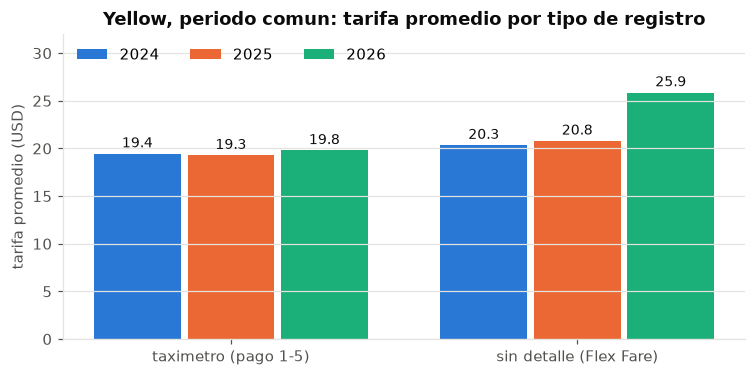

In [33]:
tar = sql("08_08_tarifa_por_tipo_registro", con_todo)
display(tar)
d = tar[tar.taxi == "yellow"]
fig, eje = plt.subplots(figsize=(8, 3.6))
tipos = ["taximetro (pago 1-5)", "sin detalle (Flex Fare)"]
anios = sorted(d.anio.unique())
for i, anio in enumerate(anios):
    v = d[d.anio == anio].set_index("tipo_registro").loc[tipos]
    barras = eje.bar([k + (i - 1) * 0.27 for k in range(2)], v.tarifa_promedio, width=0.25,
                     color=COLOR_ANIO.get(anio, TEXTO_2), label=anio)
    eje.bar_label(barras, fmt="%.1f", padding=2, color=TEXTO, fontsize=9)
eje.set_xticks(range(2), tipos)
eje.set_ylabel("tarifa promedio (USD)")
eje.set_title("Yellow, periodo comun: tarifa promedio por tipo de registro")
eje.set_ylim(0, 32)
eje.legend(ncols=3, loc="upper left")
eje.grid(axis="x", visible=False)
guardar(fig, "08_08_tarifa_por_tipo_registro")

### 8.6 Patron 3 - green pierde viajes y los aeropuertos pierden peso

In [34]:
sql("08_07_aeropuertos_por_anio", con_todo)

08_07_aeropuertos_por_anio: 3 filas en 1.56 s


,anio,viajes,pct_aeropuerto,pct_ingresos_aeropuerto,total_mediano_jfk
0,2024,25487194,10.16,28.04,89.13
1,2025,28678171,8.90,24.58,89.49
2,2026,28215140,8.17,21.05,89.01
